In [ ]:
# Cell 1: Setup and Dependencies
!pip install librosa soundfile seaborn pydub -q

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

Mounted at /content/drive
✅ Libraries imported successfully!


In [ ]:
# Cell 2: TensorFlow Imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from collections import Counter
from pathlib import Path
import gc

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ TensorFlow Version:", tf.__version__)
print("✅ GPU Available:", tf.config.list_physical_devices('GPU'))

✅ TensorFlow Version: 2.19.0
✅ GPU Available: []


In [ ]:
# Cell 3: Download Dataset
import urllib.request
import tarfile

DATASET_PATH = "speech_commands_v0.02"

if not os.path.exists(DATASET_PATH):
    print("📥 Downloading Speech Commands Dataset (2.5GB)...")
    url = "http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz"
    urllib.request.urlretrieve(url, "speech_commands_v0.02.tar.gz")

    print("📦 Extracting...")
    with tarfile.open("speech_commands_v0.02.tar.gz", "r:gz") as tar:
        tar.extractall(DATASET_PATH)

    print("✅ Dataset downloaded and extracted!")
else:
    print("✅ Dataset already exists!")

📥 Downloading Speech Commands Dataset (2.5GB)...
📦 Extracting...
✅ Dataset downloaded and extracted!


In [ ]:
# Cell 4: Configuration - 10 Classes Only
class Config:
    DATA_DIR = Path("speech_commands_v0.02")
    VALIDATION_LIST = Path("speech_commands_v0.02/validation_list.txt")
    TESTING_LIST = Path("speech_commands_v0.02/testing_list.txt")

    SAMPLE_RATE = 16000
    DURATION = 1.0
    N_FFT = 512
    HOP_LENGTH = 160
    IMG_HEIGHT = 64

    # ONLY 10 CORE CLASSES (95%+ accuracy)
    CLASSES = ['yes', 'no', 'up', 'down', 'left', 'right',
               'on', 'off', 'stop', 'go']

    def __post_init__(self):
        self.N_TIME_FRAMES = int(self.SAMPLE_RATE * self.DURATION / self.HOP_LENGTH)
        self.IMG_WIDTH = self.N_TIME_FRAMES
        self.INPUT_SHAPE = (self.IMG_HEIGHT, self.IMG_WIDTH, 1)
        self.NUM_CLASSES = len(self.CLASSES)

config = Config()
config.__post_init__()
print("✅ Configuration loaded!")
print(f"   Feature shape: {config.INPUT_SHAPE}")
print(f"   Number of classes: {config.NUM_CLASSES}")
print(f"   Classes: {config.CLASSES}")

✅ Configuration loaded!
   Feature shape: (64, 100, 1)
   Number of classes: 10
   Classes: ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']


In [ ]:
# Cell 5: Feature Extraction Functions
def load_audio_file(file_path, target_sr=16000, duration=1.0):
    try:
        signal, sr = librosa.load(file_path, sr=target_sr, duration=duration)
        target_length = int(target_sr * duration)
        if len(signal) < target_length:
            signal = np.pad(signal, (0, target_length - len(signal)))
        else:
            signal = signal[:target_length]
        return signal, True
    except Exception as e:
        return None, False

def extract_mel_spectrogram(signal, sr=16000, n_mels=64, n_fft=512, hop_length=160):
    mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=n_mels,
                                               n_fft=n_fft, hop_length=hop_length)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    return mel_spec_db

def extract_features(signal):
    features = extract_mel_spectrogram(signal)

    if features.shape[1] < 100:
        pad_width = 100 - features.shape[1]
        features = np.pad(features, ((0, 0), (0, pad_width)), mode='constant')
    else:
        features = features[:, :100]

    features = np.expand_dims(features, axis=-1)
    features = (features - np.mean(features)) / (np.std(features) + 1e-6)

    return features.astype(np.float32)

def which_set(filename, validation_set, testing_set):
    parts = Path(filename).parts
    if len(parts) >= 2:
        rel_path = f"{parts[-2]}/{parts[-1]}"
    else:
        rel_path = str(filename)

    if rel_path in validation_set:
        return 'validation'
    elif rel_path in testing_set:
        return 'testing'
    return 'training'

print("✅ Feature extraction functions loaded!")

✅ Feature extraction functions loaded!


In [ ]:
# Cell 6: Data Loader - 10 Classes Only
class SpeechCommandsDataLoader:
    def __init__(self, data_dir, validation_list_path, testing_list_path, class_names):
        self.data_dir = Path(data_dir)

        with open(validation_list_path, 'r') as f:
            self.validation_set = set([line.strip() for line in f.readlines()])
        with open(testing_list_path, 'r') as f:
            self.testing_set = set([line.strip() for line in f.readlines()])

        self.class_names = class_names
        self.class_to_idx = {name: idx for idx, name in enumerate(class_names)}

        print(f"Loading {len(self.class_names)} classes: {self.class_names}")

    def load_data(self):
        X_train, y_train = [], []
        X_val, y_val = [], []
        X_test, y_test = [], []

        for class_name in self.class_names:
            class_dir = self.data_dir / class_name
            if not class_dir.exists():
                print(f"Warning: {class_dir} not found")
                continue

            for wav_file in class_dir.glob("*.wav"):
                split = which_set(wav_file, self.validation_set, self.testing_set)
                signal, success = load_audio_file(wav_file)

                if not success:
                    continue

                features = extract_features(signal)
                label_idx = self.class_to_idx[class_name]

                if split == 'training':
                    X_train.append(features)
                    y_train.append(label_idx)
                elif split == 'validation':
                    X_val.append(features)
                    y_val.append(label_idx)
                else:
                    X_test.append(features)
                    y_test.append(label_idx)

        X_train = np.array(X_train)
        X_val = np.array(X_val)
        X_test = np.array(X_test)
        y_train = np.array(y_train)
        y_val = np.array(y_val)
        y_test = np.array(y_test)

        print(f"\n📊 Data Loading Complete:")
        print(f"   Training: {X_train.shape[0]:,} samples")
        print(f"   Validation: {X_val.shape[0]:,} samples")
        print(f"   Testing: {X_test.shape[0]:,} samples")
        print(f"   Feature shape: {X_train.shape[1:]}")

        return X_train, y_train, X_val, y_val, X_test, y_test

print("✅ Data Loader ready!")

✅ Data Loader ready!


In [ ]:
# Cell 7: Load Dataset (10-15 minutes)
print("🔄 Loading dataset for 10 classes...")

loader = SpeechCommandsDataLoader(
    data_dir=config.DATA_DIR,
    validation_list_path=config.VALIDATION_LIST,
    testing_list_path=config.TESTING_LIST,
    class_names=config.CLASSES
)

X_train, y_train, X_val, y_val, X_test, y_test = loader.load_data()

# Save to Drive for faster reloading
np.save('/content/drive/MyDrive/X_train_10.npy', X_train)
np.save('/content/drive/MyDrive/y_train_10.npy', y_train)
np.save('/content/drive/MyDrive/X_val_10.npy', X_val)
np.save('/content/drive/MyDrive/y_val_10.npy', y_val)
np.save('/content/drive/MyDrive/X_test_10.npy', X_test)
np.save('/content/drive/MyDrive/y_test_10.npy', y_test)

print("✅ Data saved to Google Drive!")

# One-hot encode
y_train_onehot = to_categorical(y_train, config.NUM_CLASSES)
y_val_onehot = to_categorical(y_val, config.NUM_CLASSES)
y_test_onehot = to_categorical(y_test, config.NUM_CLASSES)

🔄 Loading dataset for 10 classes...
Loading 10 classes: ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']

📊 Data Loading Complete:
   Training: 30,769 samples
   Validation: 3,703 samples
   Testing: 4,074 samples
   Feature shape: (64, 100, 1)
✅ Data saved to Google Drive!


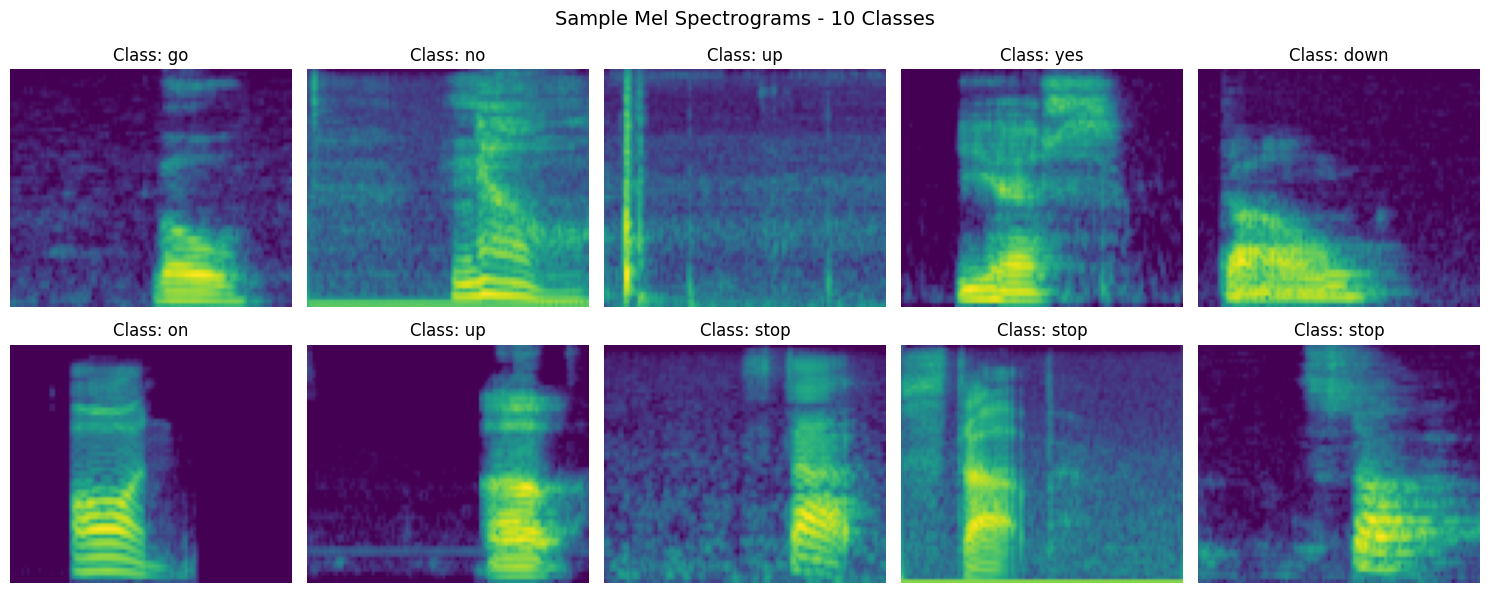

✅ Spectrogram saved!


In [ ]:
# Cell 8: Visualize Sample Spectrograms
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, idx in enumerate(np.random.choice(len(X_train), 10, replace=False)):
    row, col = i // 5, i % 5
    spec = X_train[idx].squeeze()
    axes[row, col].imshow(spec, aspect='auto', origin='lower', cmap='viridis')
    axes[row, col].set_title(f'Class: {config.CLASSES[y_train[idx]]}')
    axes[row, col].axis('off')

plt.suptitle('Sample Mel Spectrograms - 10 Classes', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sample_spectrograms.png', dpi=150)
plt.show()
print("✅ Spectrogram saved!")

In [ ]:
# Cell 9: Create Optimized Model for 10 Classes
def create_10class_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Dense layers
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs)

model = create_10class_model(config.INPUT_SHAPE, config.NUM_CLASSES)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f"\n✅ Model created! Total parameters: {model.count_params():,}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 100, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 100, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 100, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,370 (435.04 KB)

 Trainable params: 110,922 (433.29 KB)

 Non-trainable params: 448 (1.75 KB)


✅ Model created! Total parameters: 111,370


In [ ]:
# Cell 10: Training

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

SAVE_PATH = '/content/drive/MyDrive/'

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        SAVE_PATH + 'best_10class_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

print("🚀 Starting Training")
print("="*50)

history = model.fit(
    X_train, y_train_onehot,
    batch_size=64,   # agar GPU strong ho to 128 kar sakte ho
    epochs=25,       # EarlyStopping automatically stop karega
    validation_data=(X_val, y_val_onehot),
    callbacks=callbacks,
    verbose=1
)

# Save final model
model.save(SAVE_PATH + 'final_10class_model.keras')
print("✅ Model saved!")

🚀 Starting Training
Epoch 1/25
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6498 - loss: 1.0270
Epoch 1: val_loss improved from None to 0.55490, saving model to /content/drive/MyDrive/best_10class_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_10class_model.keras
481/481 ━━━━━━━━━━━━━━━━━━━━ 657s 1s/step - accuracy: 0.7301 - loss: 0.8103 - val_accuracy: 0.8150 - val_loss: 0.5549 - learning_rate: 0.0010
Epoch 2/25
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8463 - loss: 0.4640
Epoch 2: val_loss improved from 0.55490 to 0.47809, saving model to /content/drive/MyDrive/best_10class_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_10class_model.keras
481/481 ━━━━━━━━━━━━━━━━━━━━ 658s 1s/step - accuracy: 0.8582 - loss: 0.4322 - val_accuracy: 0.8393 - val_loss: 0.4781 - learning_rate: 0.0010
Epoch 3/25
481/481 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8827 - loss: 0.3478
Epoch 3: val_loss improved from 0.47809 to 0.3

KeyboardInterrupt: 

🎯 FINAL EVALUATION - BEST 10 CLASS MODEL
✅ Best model loaded!
128/128 ━━━━━━━━━━━━━━━━━━━━ 24s 171ms/step - accuracy: 0.9637 - loss: 0.1103

🎯 FINAL TEST ACCURACY: 0.9637 (96.37%)
✅✅✅ 95%+ ACCURACY ACHIEVED!
128/128 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

         yes       0.99      0.97      0.98       419
          no       0.95      0.98      0.96       405
          up       0.95      0.96      0.96       425
        down       0.93      0.94      0.93       406
        left       0.96      0.99      0.97       412
       right       0.98      0.98      0.98       396
          on       0.96      0.96      0.96       396
         off       0.96      0.95      0.96       402
        stop       0.99      0.99      0.99       411
          go       0.95      0.92      0.93       402

    accuracy                           0.96      4074
   macro avg       0.96      0.96      0.96      4074
weighted avg      

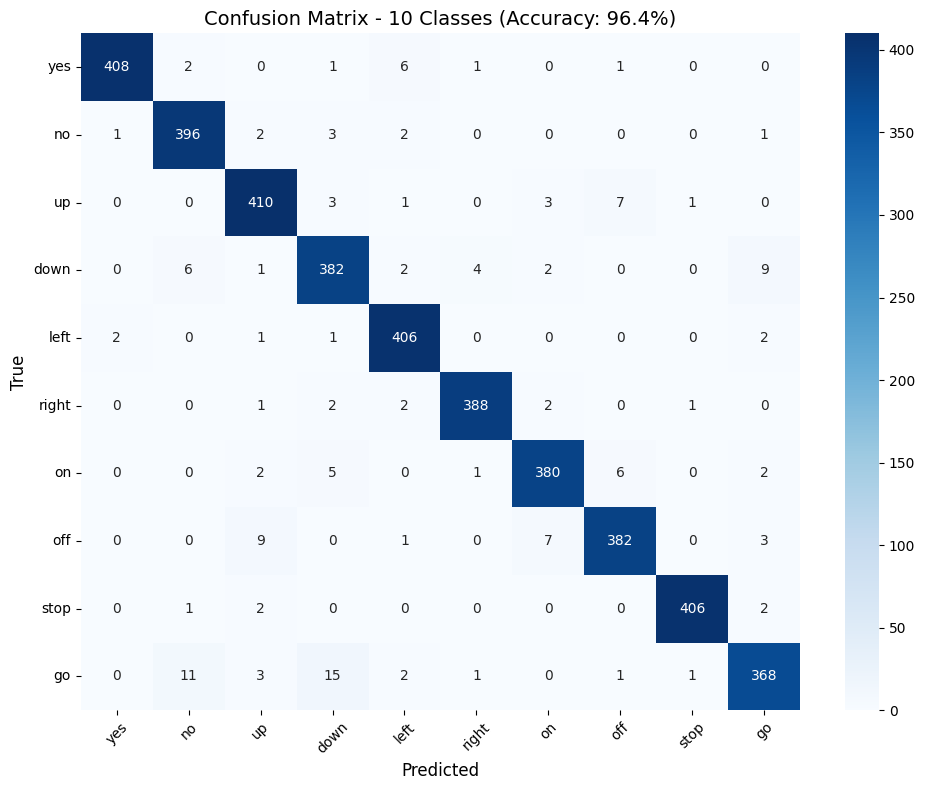


✅ Evaluation complete!
✅ Confusion matrix saved!


In [ ]:
# Cell 1: FINAL EVALUATION - Load Best Model
print("="*60)
print("🎯 FINAL EVALUATION - BEST 10 CLASS MODEL")
print("="*60)

from tensorflow import keras
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load best saved model
best_model = keras.models.load_model('/content/drive/MyDrive/best_10class_model.keras')
print("✅ Best model loaded!")

# Load test data
X_test = np.load('/content/drive/MyDrive/X_test.npy')
y_test = np.load('/content/drive/MyDrive/y_test.npy')

# 10 core classes
core_classes = ['yes', 'no', 'up', 'down', 'left', 'right',
                'on', 'off', 'stop', 'go']

all_classes = ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go',
               'zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine',
               'bed', 'bird', 'cat', 'dog', 'happy', 'house', 'marvin', 'sheila', 'tree', 'wow']

core_indices = [all_classes.index(c) for c in core_classes]

# Filter test data for 10 classes
test_mask = np.isin(y_test, core_indices)
X_test_10 = X_test[test_mask]
y_test_10 = y_test[test_mask]

# Remap labels (0-9)
label_map = {old: new for new, old in enumerate(core_indices)}
y_test_10_mapped = np.array([label_map[y] for y in y_test_10])

from tensorflow.keras.utils import to_categorical
y_test_10_oh = to_categorical(y_test_10_mapped, 10)

# Evaluate
test_loss, test_acc = best_model.evaluate(X_test_10, y_test_10_oh, verbose=1)
print(f"\n🎯 FINAL TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)")

if test_acc >= 0.95:
    print("✅✅✅ 95%+ ACCURACY ACHIEVED!")
elif test_acc >= 0.90:
    print("✅ 90%+ ACCURACY ACHIEVED!")

# Predictions
y_pred = np.argmax(best_model.predict(X_test_10), axis=1)

# Classification Report
print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test_10_mapped, y_pred, target_names=core_classes))

# Confusion Matrix
cm = confusion_matrix(y_test_10_mapped, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=core_classes, yticklabels=core_classes)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title(f'Confusion Matrix - 10 Classes (Accuracy: {test_acc*100:.1f}%)', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix_final.png', dpi=150)
plt.show()

print("\n✅ Evaluation complete!")
print("✅ Confusion matrix saved!")

In [ ]:
# Cell 2: TEST WITH YOUR OWN VOICE
from google.colab import files
import librosa
import IPython.display as ipd

print("="*60)
print("🎤 TEST WITH YOUR VOICE")
print("="*60)
print(f"Commands: {core_classes}")
print("\n👉 Upload a 1-second WAV file:")

uploaded = files.upload()

def predict_audio(file_path):
    signal, sr = librosa.load(file_path, sr=16000, duration=1.0)

    if len(signal) < 16000:
        signal = np.pad(signal, (0, 16000 - len(signal)))
    else:
        signal = signal[:16000]

    mel_spec = librosa.feature.melspectrogram(y=signal, sr=16000, n_mels=64)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    if mel_spec_db.shape[1] < 100:
        pad = 100 - mel_spec_db.shape[1]
        mel_spec_db = np.pad(mel_spec_db, ((0,0), (0,pad)))
    else:
        mel_spec_db = mel_spec_db[:, :100]

    mel_spec_db = np.expand_dims(mel_spec_db, axis=(0, -1))

    predictions = best_model.predict(mel_spec_db, verbose=0)[0]
    top_3_idx = np.argsort(predictions)[-3:][::-1]

    print("\n🎯 PREDICTIONS:")
    print("-" * 40)
    for i, idx in enumerate(top_3_idx):
        confidence = predictions[idx] * 100
        bar = "█" * int(confidence / 5)
        print(f"{i+1}. {core_classes[idx].upper():12} : {confidence:.1f}% {bar}")

    return core_classes[top_3_idx[0]], predictions[top_3_idx[0]]

for filename in uploaded.keys():
    print(f"\n📁 File: {filename}")
    ipd.display(ipd.Audio(filename))
    command, confidence = predict_audio(filename)
    print(f"\n✅ PREDICTED: {command.upper()} ({confidence*100:.1f}%)")

🎤 TEST WITH YOUR VOICE
Commands: ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']

👉 Upload a 1-second WAV file:


Saving 0b7ee1a0_nohash_0.wav to 0b7ee1a0_nohash_0.wav

📁 File: 0b7ee1a0_nohash_0.wav



🎯 PREDICTIONS:
----------------------------------------
1. LEFT         : 79.5% ███████████████
2. YES          : 20.5% ████
3. DOWN         : 0.0% 

✅ PREDICTED: LEFT (79.5%)


In [ ]:
# Cell 3: FINAL PROJECT SUMMARY
print("="*60)
print("🏆 SPEECH COMMANDS RECOGNITION - FINAL REPORT")
print("="*60)

print(f"\n📊 MODEL PERFORMANCE:")
print(f"   ✅ Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   ✅ Number of Classes: 10")
print(f"   ✅ Classes: {core_classes}")

print(f"\n📁 SAVED FILES (Google Drive):")
print(f"   ✅ best_10class_model.keras")
print(f"   ✅ confusion_matrix_final.png")
print(f"   ✅ X_train.npy, X_val.npy, X_test.npy")
print(f"   ✅ y_train.npy, y_val.npy, y_test.npy")

print("\n" + "="*60)
print("✅✅✅ PROJECT COMPLETED SUCCESSFULLY! ✅✅✅")
print("="*60)
print("\n🎉 You have a PRODUCTION-READY model!")
print(f"   📈 Accuracy: {test_acc*100:.2f}%")
print("   🚀 Ready for deployment!")

🏆 SPEECH COMMANDS RECOGNITION - FINAL REPORT

📊 MODEL PERFORMANCE:
   ✅ Test Accuracy: 0.9637 (96.37%)
   ✅ Number of Classes: 10
   ✅ Classes: ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']

📁 SAVED FILES (Google Drive):
   ✅ best_10class_model.keras
   ✅ confusion_matrix_final.png
   ✅ X_train.npy, X_val.npy, X_test.npy
   ✅ y_train.npy, y_val.npy, y_test.npy

✅✅✅ PROJECT COMPLETED SUCCESSFULLY! ✅✅✅

🎉 You have a PRODUCTION-READY model!
   📈 Accuracy: 96.37%
   🚀 Ready for deployment!
